In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

In [2]:
df = pd.read_csv("tripadvisor_european_restaurants.csv")

df.shape[0]

C:\Users\Admin\AppData\Local\Temp\ipykernel_32292\4173993848.py:1: DtypeWarning: Columns (0: region) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("tripadvisor_european_restaurants.csv")


1083397

**1. Data Preprocessing and Feature Engineering**

vegetarian_friendly: 324017 positive out of 1083397
vegan_options: 136597 positive out of 1083397
gluten_free: 123497 positive out of 1083397
           cuisines  vegetarian_friendly  health_score   food  quality_score
0            french                    0             0  0.750          3.125
1                                      0             0  0.750          3.000
2  french, european                    0             0  0.750          3.000
3            french                    0             0  0.875          3.375
4            french                    0             0  0.875          3.375


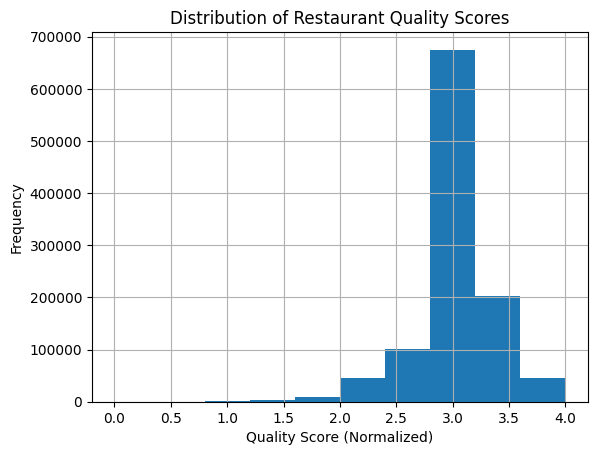

In [3]:
# ------------------ Clean and standardize: ------------------
columns = ["cuisines", "top_tags", "keywords"]

for col in columns:
    # convert to string, lowercase, and strip leading spaces
    # replace the missing value NaN with an empty string 
    df[col] = df[col].fillna("").astype(str).str.lower().str.strip()

# ------------------ Convert dietary features into binary variables ------------------
dietary_features = ["vegetarian_friendly", "vegan_options", "gluten_free"]

for col in dietary_features: 
    df[col] = df[col].astype(str).str.strip().apply(  
        lambda x: 1 if x.lower() == 'y' else 0     
    )

# ------------------ Normalize rating-related attributes (food, service, value, atmosphere) ------------------
rating_attributes = ["food", "service", "value", "atmosphere"]

for col in rating_attributes:
    df[col] = df[col].fillna(df[col].median())

scaler = MinMaxScaler()
df[rating_attributes] = scaler.fit_transform(df[rating_attributes])

#------------------ Create derived features ----------------------

# Health Score: Sum of the dietary options (0 = none, 3 = caters to all)
df["health_score"] = df[dietary_features].sum(axis=1)

df["quality_score"] = df[rating_attributes].sum(axis=1)

# See the actual raw values to catch any other variants
for col in dietary_features:
    print(f"{col}: {df[col].sum()} positive out of {len(df)}")

print(df[['cuisines', 'vegetarian_friendly', 'health_score', 'food', 'quality_score']].head())
df['quality_score'].hist()

import matplotlib.pyplot as plt

# Assuming you plotted it like this: df['quality_score'].hist()
plt.title('Distribution of Restaurant Quality Scores')
plt.xlabel('Quality Score (Normalized)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

**2. Regional Grouping and Sampling**

In [4]:
# clean the data 
df["country"] = df["country"].fillna("").astype("str").str.strip().str.title()

# --------------------- map countries to their regions, and Finland remains Finland ----------------
region_mapping = {
    'Finland': 'Finland', 
    
    'Sweden': 'Northern Europe', 
    'Denmark': 'Northern Europe',
    
    'France': 'Western Europe', 'The Netherlands': 'Western Europe', 
    'Germany': 'Western Europe', 'Austria': 'Western Europe', 'Belgium': 'Western Europe',
    'England': 'Western Europe', 'Northern Ireland': 'Western Europe', 
    'Scotland': 'Western Europe', 'Wales': 'Western Europe', 'Ireland': 'Western Europe',
    
    'Spain': 'Southern Europe', 'Italy': 'Southern Europe', 
    'Greece': 'Southern Europe', 'Croatia': 'Southern Europe', 'Portugal': 'Southern Europe',
    
    'Poland': 'Eastern Europe', 'Slovakia': 'Eastern Europe', 
    'Czech Republic': 'Eastern Europe', 'Hungary': 'Eastern Europe', 
    'Bulgaria': 'Eastern Europe', 'Romania': 'Eastern Europe'
}

df["region_group"] = df["country"].map(region_mapping)

# ---------------- Determine the balanced sample size (the number of restaurants in Finland) --------------
finland_count = len(df[df["region_group"] == "Finland"])
print(f"Total restaurants in Finland: {finland_count}")

# ------------------ perform balanced sampling -----------------------
filtered_nonmatch = df.dropna(subset=["region_group"])

# Group by the new 'region_group' column, and randomly sample 'finland_count' rows from each.
# replace=True in case a region (like Northern Europe) has slightly fewer restaurants than Finland.
# replace=True duplicates a few rows to make up the difference.
balanced = filtered_nonmatch.groupby("region_group").sample(n=finland_count, replace=True, random_state=42)

# Verify that the sampling worked and all regions have the exact same number of rows
print("\nBalanced Dataset Counts:")
print(balanced['region_group'].value_counts())

Total restaurants in Finland: 7372

Balanced Dataset Counts:
region_group
Eastern Europe     7372
Finland            7372
Northern Europe    7372
Southern Europe    7372
Western Europe     7372
Name: count, dtype: int64


**3. Restaurant–Cuisine Bipartite Network**

- A bipartite network is a graph that has two distinct types of nodes. In this case, one row will be "Restaurants" and the other row will be "Cuisines". Edges (lines) can only connect a restaurant to a cuisine; restaurants cannot connect directly to other restaurants in this specific graph.
- A cuisine–cuisine network (shared restaurants): squish the graph down so it only looks at the cuisines, drawing lines between two cuisines if they are frequently served at the same restaurant

In [5]:
import networkx as nx
from networkx.algorithms import bipartite

# empty graph
B = nx.Graph()

# -------------------------- construct the bipartite graph ----------------------------------
for index, row in balanced.iterrows():
    # use restaurant_link as an ID instead of restaurant_names which may have duplicates
    restaurant_id = row["restaurant_link"]

    cuisine_str = str(row["cuisines"])

    # split for more than 1 items listed in the 'cuisines' column
    cuisine_list = [c.strip() for c in cuisine_str.split(",")]

    B.add_node(restaurant_id, bipartite=0, type="restaurant")

    for cuisine in cuisine_list: 
        if cuisine: # ensure not an empty string
            B.add_node(cuisine, bipartite=1, type='cuisine')
            B.add_edge(restaurant_id, cuisine)

print(f"Bipartite Network created with {B.number_of_nodes()} nodes and {B.number_of_edges()} edges.")

# ------------------- project into cuisine–cuisine network (shared restaurants) -------------------

# separate just the cuisine nodes
cuisine_nodes = [n for n,d in B.nodes(data=True) if d["bipartite"] == 1]

cuisine_network = bipartite.projected_graph(B, cuisine_nodes)

print(f"Projected Cuisine Network created with {cuisine_network.number_of_nodes()} cuisines connected by {cuisine_network.number_of_edges()} edges.")

Bipartite Network created with 32857 nodes and 63929 edges.
Projected Cuisine Network created with 148 cuisines connected by 2882 edges.


Code explanation:
`[n for n,d in B.nodes(data=True) if d["bipartite"] == 1]` 
- `B.nodes()` normally would just gives a basic list of the node names (e.g., `['Italian', 'Pizza', 'g10001637...']`).
- Add `data=True` gives a list of tuples (pairs of items), where the first item is the node's name, and the second item is a dictionary of all the data attached to it.
`[ ('g10001637-d10002227', {'bipartite': 0, 'type': 'restaurant'}), ('Italian', {'bipartite': 1, 'type': 'cuisine'}) ]`

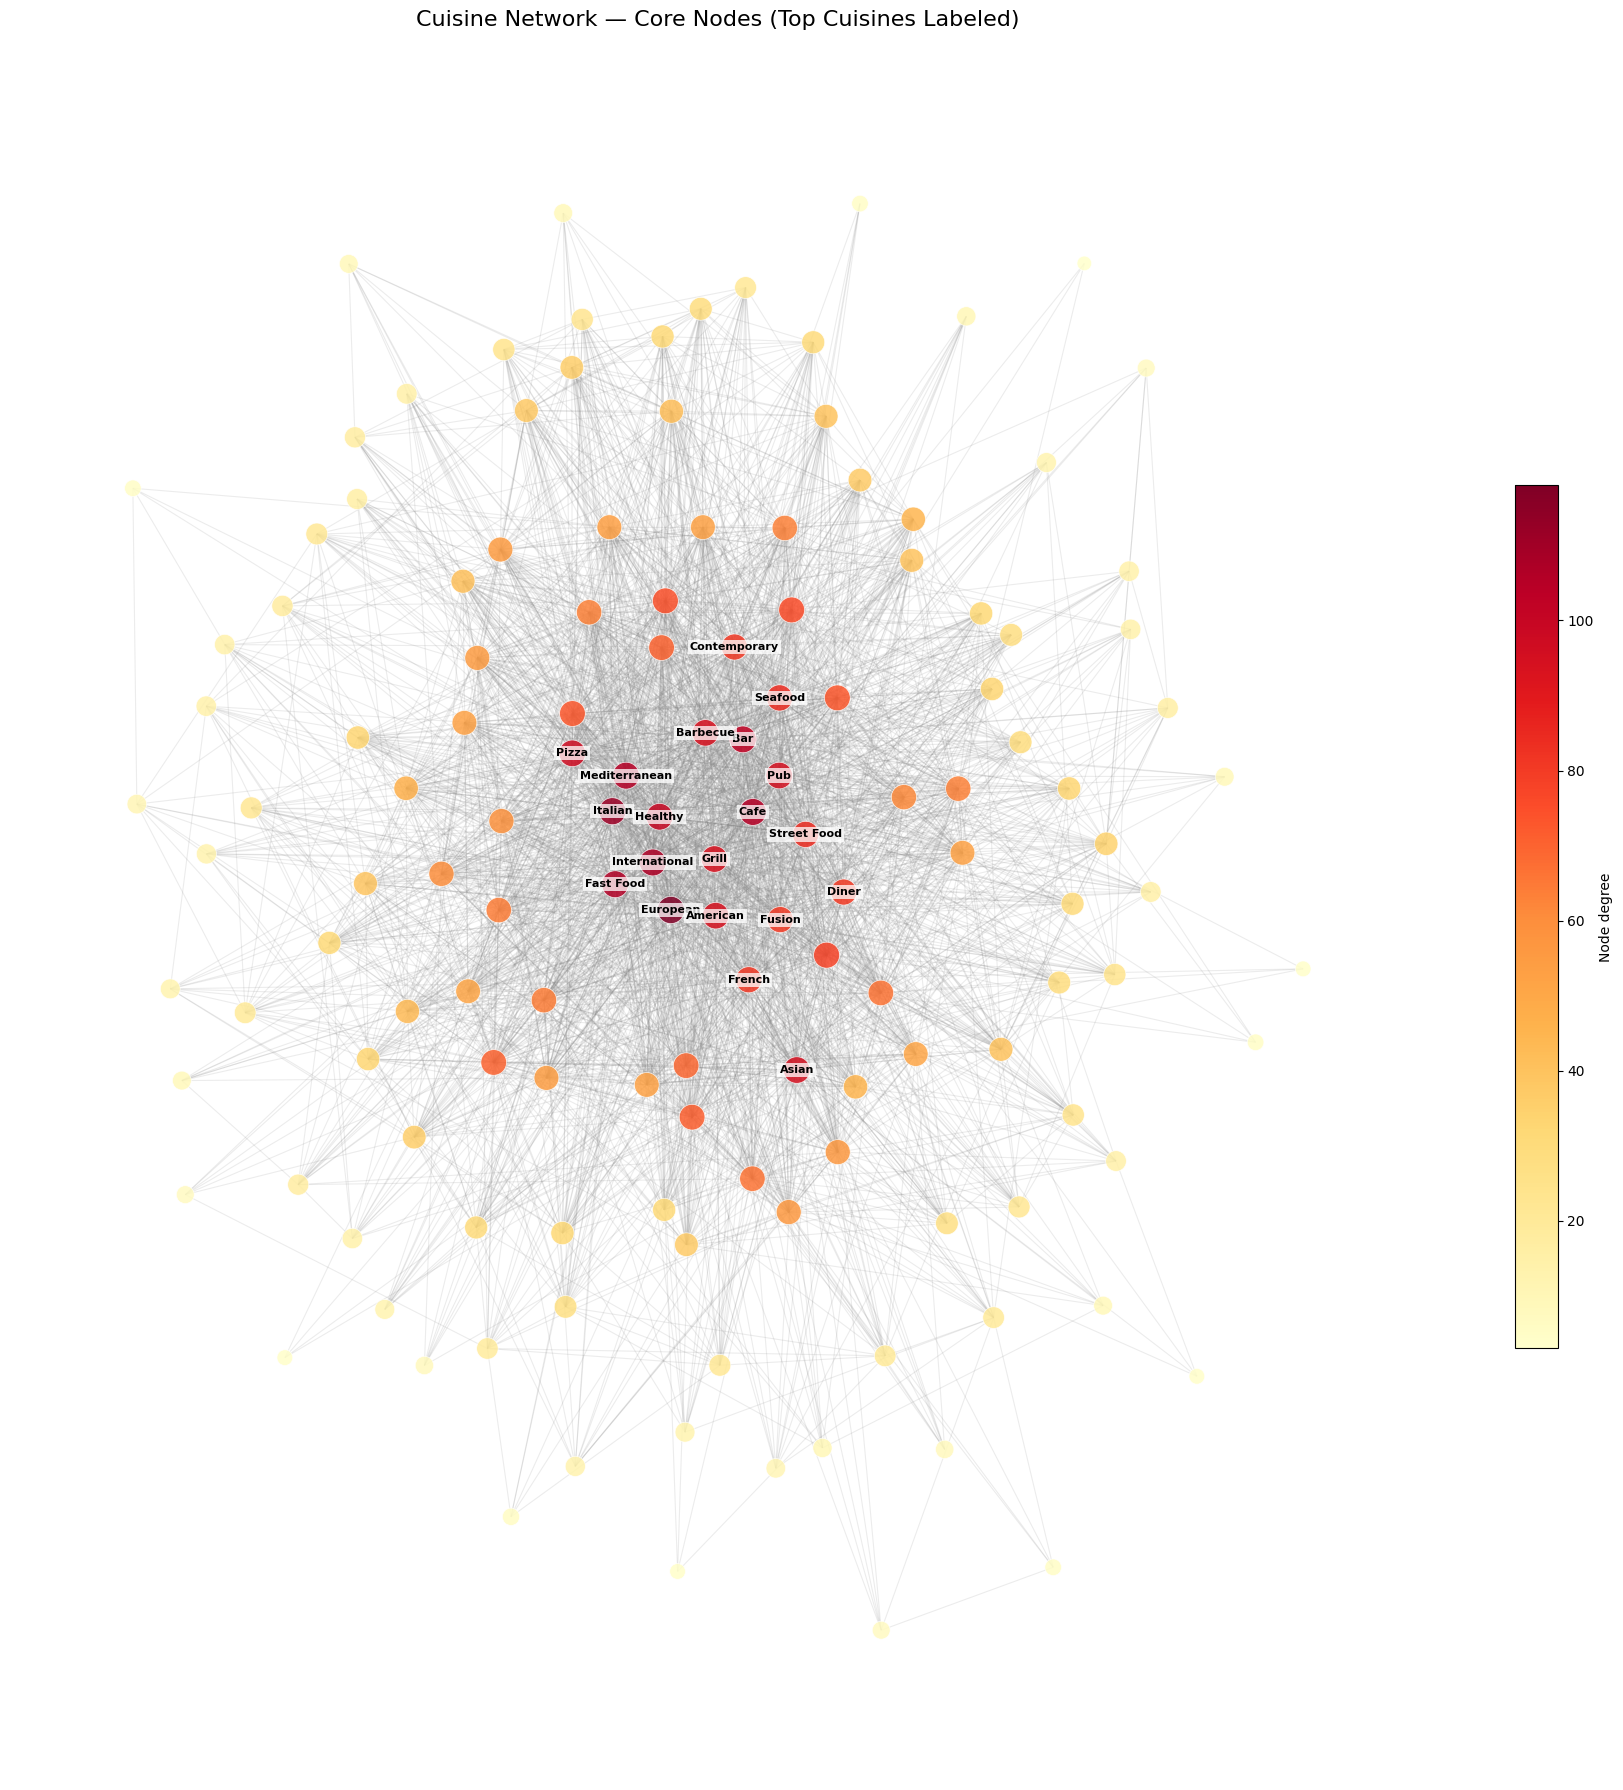

In [6]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# Reduce edge clutter: keep only edges above a weight threshold
# If edges have weights, filter by them; otherwise, keep only
# edges connecting nodes with degree > some threshold
threshold_degree = 3  
core_nodes = [n for n, d in cuisine_network.degree() if d >= threshold_degree]
subgraph = cuisine_network.subgraph(core_nodes)

# use kamada_kawai for cleaner layout 
degrees = dict(subgraph.degree())

try:
    pos = nx.kamada_kawai_layout(subgraph)
except Exception:
    pos = nx.spring_layout(subgraph, k=2.5 / np.sqrt(len(subgraph)), 
                           iterations=200, seed=42)

# Log-scale node sizes to avoid massive hub nodes 
node_sizes = [np.log1p(d) * 80 for d in degrees.values()]

# Color nodes by degree (community feel)
degree_vals = list(degrees.values())
norm = plt.Normalize(vmin=min(degree_vals), vmax=max(degree_vals))
node_colors = [plt.cm.YlOrRd(norm(d)) for d in degree_vals]

fig, ax = plt.subplots(figsize=(18, 18))

nx.draw_networkx_edges(
    subgraph, pos,
    alpha=0.15,        
    width=0.8,
    edge_color='gray',
    ax=ax
)

nx.draw_networkx_nodes(
    subgraph, pos,
    node_size=node_sizes,
    node_color=node_colors,
    alpha=0.85,
    linewidths=0.5,
    edgecolors='white',
    ax=ax
)

# --- 6. Label only top N hubs ---
top_n = 20
top_cuisines = sorted(degrees, key=degrees.get, reverse=True)[:top_n]
labels = {n: n.title() for n in top_cuisines}

nx.draw_networkx_labels(
    subgraph, pos, labels,
    font_size=8,
    font_weight='bold',
    bbox=dict(facecolor='white', edgecolor='none', alpha=0.75, pad=1.5),
    ax=ax
)

# colorbar for degree
sm = plt.cm.ScalarMappable(cmap=plt.cm.YlOrRd, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, shrink=0.5, label='Node degree')

ax.set_title("Cuisine Network — Core Nodes (Top Cuisines Labeled)", fontsize=16, pad=20)
ax.axis('off')
plt.tight_layout()
plt.show()

**4. Restaurant Similarity Network (Attribute-Based)**

- Memory management: The balanced dataset has about 36,860 restaurants (7,372 $\times$ 5). Comparing every single restaurant to every other restaurant to see if they are similar means calculating over 1.3 billion possible connections. If try to build a dense matrix for this, computer will likely run out of RAM and crash.
- Solution: use Sparse Matrices (which only remember the strong connections) and set a Similarity Threshold (meaning we only draw an edge if the restaurants are, for example, at least 80% similar).
- Also, calculate it in "chunks" of 1,000 rows. We look at 1,000 restaurants, find only their $>0.85$ matches, save those as edges, and then throw the matrix away to free up the memory before moving to the next 1,000.

**Define the similarity score metric**
- The most standard mathematical approach is to convert everything into numbers and use **Cosine Similarity** for the mixed set of texts (cuisines, keywords) and numbers (price, dietary) criteria.

    - Text (Cuisines & Keywords): combine these into a single "bag of words" and use a tool called `TfidfVectorizer` to turn them into numerical values based on how rare or common the tags are.
    - Numbers (Price & Dietary): map price to numbers (1, 2, 3) and use the binary dietary features (0 or 1).
    - The Score: stack all these numbers together and calculate the Cosine angle between them. 1.0 means identical, 0.0 means completely different.

In [8]:
import pandas as pd
import numpy as np
import networkx as nx
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler, normalize
from scipy.sparse import hstack, csr_matrix

# ------------------------------- Prepare features -------------------------------------

# clean and combine text features
balanced["text_features"] = balanced["cuisines"].fillna("") + " " + balanced["keywords"].fillna("")

# limit to top 500 features to save memory
text_matrix = TfidfVectorizer(max_features=500).fit_transform(balanced["text_features"])

# prepare numerical features
dietary_features = ["vegetarian_friendly", "vegan_options", "gluten_free"]

# then extract them to a separate data frame
# create a CSR or Compressed Sparse Row: slice the data by row and remove all null values (= 0)
dietary_matrix = csr_matrix(balanced[dietary_features].values)

# map the Euro-based price levels to numeric values
price_mapping = {
    '€': 1, 
    '€€-€€€': 2, 
    '€€€€': 3
}

# apply the mapping
# if restaurant null, we map it with 2
balanced["price_num"] = balanced["price_level"].map(price_mapping).fillna(2)

# scale price to 0-1
price_scaled = MinMaxScaler().fit_transform(balanced[["price_num"]])
price_matrix = csr_matrix(price_scaled)

# -------------------------- combine into a single feauture matrix ------------------------
combined_features = hstack([text_matrix, dietary_matrix, price_matrix])
combined_features = combined_features.astype(np.float32) 

print(f"Combined feature matrix shape: {combined_features.shape}")

# --------------------------- calculate Similarity score and build network ------------------------

# Cosine Similarity: perform dot product 
# (apply L2-normalize once upfront so dot product == cosine similarity)
combined_norm = normalize(combined_features, norm="l2")

G_similarity = nx.Graph()
# add all restaurant nodes
restaurant_id_list = balanced["restaurant_link"].tolist()
G_similarity.add_nodes_from(restaurant_id_list)

# set threshold: connect only if > 85% similar 
THRESHOLD = 0.85

chunks = 500
restaurant_num = combined_features.shape[0]

#iterate through the steps of 500
for i in range(0, restaurant_num, chunks):
    # Define the chunk boundary
    end = min(i + chunks, restaurant_num)
    chunk = combined_features[i:end]

    # perform cosine similarity (dot product) for this chunk
    # steps:
    # 1. transpose combined_norm.T so rows become cols and vice versa
    # 2. sparse dot product using @, a matrix multiplication operator -> give a sparse result
    # 3. convert to array to make the sparse result into a dense array
    similarity_chunk = (chunk @ combined_norm.T).toarray()

    # extract strong connections for this chunk
    edges = []
    for j in range(similarity_chunk.shape[0]):
        row_id = i + j

        # Return valid col indices  licates (A-B and B-A) and self-loops (A-A)
        # steps: 
        # 1. Conditions with &: 
        # similarity_chunk[j] > THRESHOLD — only highly similar pairs
        # np.arange(restaurant_num) > row_id — only columns ahead of the current row, 
        # which prevents adding duplicate edges (A-B and B-A) and self-loops (A-A)
        # 2. np.where(...)[0] returns the column indices that satisfy both conditions (&)
        valid_cols = np.where((similarity_chunk[j] > THRESHOLD) & (np.arange(restaurant_num) > row_id))[0]

        for col_id in valid_cols:
            edges.append((restaurant_id_list[row_id], restaurant_id_list[col_id]))
    
    G_similarity.add_edges_from(edges)



print(f"Similarity Network created")
print(f"Nodes: {G_similarity.number_of_nodes()}")
print(f"Edges: {G_similarity.number_of_edges()}")

Combined feature matrix shape: (36860, 504)
Similarity Network created
Nodes: 32709
Edges: 18662117


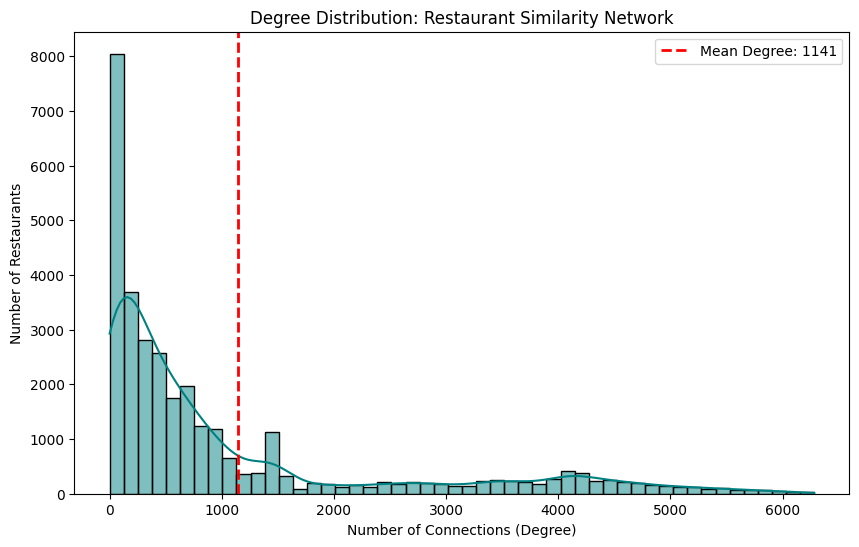

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# get  all degrees (number of connections per restaurant)
degrees_sim = [d for n, d in G_similarity.degree()]

plt.figure(figsize=(10, 6))
# use the 99th percentile to cut off extreme outliers to make the chart readable
max_plot_degree = np.percentile(degrees_sim, 99)

sns.histplot([d for d in degrees_sim if d < max_plot_degree], bins=50, kde=True, color='teal')

plt.title("Degree Distribution: Restaurant Similarity Network")
plt.xlabel("Number of Connections (Degree)")
plt.ylabel("Number of Restaurants")
plt.axvline(np.mean(degrees_sim), color='red', linestyle='dashed', linewidth=2, label=f'Mean Degree: {np.mean(degrees_sim):.0f}')
plt.legend()
plt.show()

**5. Review-Based Correlation Network**

- Goal: Construct a network where edges connect restaurants if they have similar `food`, `service`, `value`, and `atmosphere` scores. This creates a "quality similarity network".

- For memory management, use the **same chunking solution** as above.
- **Input**: feed the algorithm the four normalized rating columns created back in Task 1.
- **Threshold**: as review scores are clustered together (a massive percentage of restaurants have 4-star or 5-star averages across the board), need a strict threshold up to `0.98` to connect only restaurants with nearly identical rating profiles.

In [10]:
import numpy as np
import networkx as nx
from sklearn.neighbors import NearestNeighbors

# ----------------------------- prepare features ----------------------------------
rating_attributes = ["food", "service", "value", "atmosphere"]

# convert to Numpy array for fast computing
rating_features = balanced[rating_attributes].fillna(0).values.astype(np.float32)

# ----------------------------- use KNN to limit connections ----------------------
print("Calculating Top 10 closest neighbors to save RAM...")

# use n_neighbors=11 because the algorithm counts a restaurant as its own #1 neighbor
knn = NearestNeighbors(n_neighbors=11, metric='euclidean', n_jobs=-1)
knn.fit(rating_features)

# calculates the distances and the index numbers of the neighbors
distances, indices = knn.kneighbors(rating_features)

# ----------------------------- build Network -------------------------------------
G_quality = nx.Graph()
restaurant_id_list = balanced["restaurant_link"].tolist()
G_quality.add_nodes_from(restaurant_id_list)

edges = []
DIST_THRESHOLD = 0.05  

# Loop through our results and build the edges
for i in range(len(indices)):
    row_id = restaurant_id_list[i]
    
    # Start at 1 to skip the 0th neighbor (which is just the restaurant connecting to itself)
    for j in range(1, len(indices[i])): 
        
        # Only connect if they are actually similar
        if distances[i][j] < DIST_THRESHOLD:
            col_idx = indices[i][j]
            col_id = restaurant_id_list[col_idx]
            edges.append((row_id, col_id))

print(f"Adding {len(edges)} edges to the graph...")
G_quality.add_edges_from(edges)

print("\nQuality Similarity Network created!")
print(f"Nodes: {G_quality.number_of_nodes()}")
print(f"Edges: {G_quality.number_of_edges()}")


Calculating Top 10 closest neighbors to save RAM...
Adding 363478 edges to the graph...

Quality Similarity Network created!
Nodes: 32709
Edges: 311881


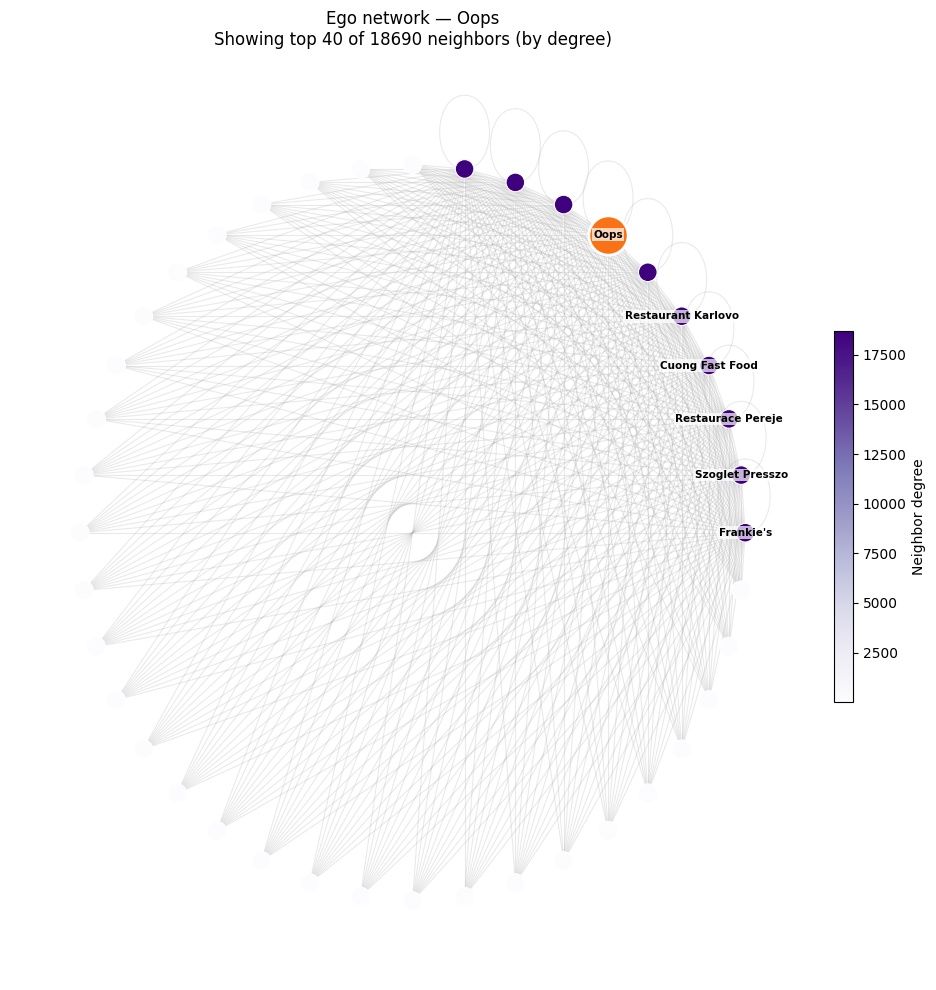

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import networkx as nx

id_to_name = dict(zip(balanced["restaurant_link"], balanced["restaurant_name"]))

# Fast: raw degree, no centrality computation
top_benchmark_id = max(G_quality.degree(), key=lambda x: x[1])[0]
top_benchmark_name = id_to_name.get(top_benchmark_id, "Benchmark Restaurant")

# Only keep top 40 neighbors by degree — rest are visual noise anyway
all_neighbors = list(G_quality.neighbors(top_benchmark_id))
top_neighbors = sorted(all_neighbors, key=lambda n: G_quality.degree(n), reverse=True)[:40]

# Manual circular layout — zero iteration cost
angles = np.linspace(0, 2 * np.pi, len(top_neighbors), endpoint=False)
pos = {top_benchmark_id: (0, 0)}
pos.update({n: (np.cos(a), np.sin(a)) for n, a in zip(top_neighbors, angles)})

# Build subgraph from just these nodes
display_nodes = [top_benchmark_id] + top_neighbors
subgraph = G_quality.subgraph(display_nodes)

# Color neighbors by their degree (connection strength)
neighbor_degrees = np.array([G_quality.degree(n) for n in top_neighbors])
norm = plt.Normalize(neighbor_degrees.min(), neighbor_degrees.max())
neighbor_colors = plt.cm.Purples(norm(neighbor_degrees))

fig, ax = plt.subplots(figsize=(10, 10))

# Edges first (behind nodes)
nx.draw_networkx_edges(subgraph, pos, ax=ax, alpha=0.25, edge_color='#aaaaaa', width=0.8)

# Neighbor nodes colored by degree
nx.draw_networkx_nodes(subgraph, pos, nodelist=top_neighbors,
                       node_color=neighbor_colors, node_size=180,
                       edgecolors='white', linewidths=0.8, ax=ax)

# Ego node
nx.draw_networkx_nodes(subgraph, pos, nodelist=[top_benchmark_id],
                       node_color='#F97316', node_size=800,
                       edgecolors='white', linewidths=2, ax=ax)

# Label only the ego node + top 5 neighbors
top5 = top_neighbors[:5]
label_nodes = [top_benchmark_id] + top5
labels = {n: id_to_name.get(n, str(n))[:20] for n in label_nodes}
nx.draw_networkx_labels(subgraph, pos, labels=labels, ax=ax,
                        font_size=7.5, font_weight='bold',
                        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=1))

# Colorbar for neighbor degree
sm = plt.cm.ScalarMappable(cmap='Purples', norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, shrink=0.4, pad=0.02, label='Neighbor degree')

total_neighbors = len(all_neighbors)
ax.set_title(
    f"Ego network — {top_benchmark_name}\n"
    f"Showing top 40 of {total_neighbors} neighbors (by degree)",
    fontsize=12
)
ax.axis('off')
plt.tight_layout()
plt.show()

**6. Global Network Analysis (Per Network Type)**

In [12]:
import networkx as nx
from networkx.algorithms import approximation

networks = {
    "Cuisine network": cuisine_network, 
    "Attribute Similarity Network": G_similarity,  
    "Quality Network": G_quality
}

for name, graph in networks.items():
    print(f"--- {name} ---")

    nodes_num = graph.number_of_nodes()
    edges_num = graph.number_of_edges()
    print(f"Nodes: {nodes_num}")
    print(f"Edges: {edges_num}")

    # Density (How close the graph is to being fully connected)
    density = nx.density(graph)
    print(f"Density: {density:.6f}")

    # Average Degree (Average number of connections per node)
    if nodes_num > 0:
        avg_degree = (2 * edges_num) / nodes_num
    else:
        avg_degree = 0
    print(f"Average Degree: {avg_degree:.2f}")

    # Clustering Coefficient 
    # (WARNING: If a graph has >1 million edges, skip this metric or it will take hours)
    if edges_num < 500000:
        avg_clustering = approximation.average_clustering(graph, trials=10000, seed=42)
        print(f"Average Clustering Coefficient: {avg_clustering:.4f}\n")
    else:
        print("Average Clustering Coefficient: Skipped (Graph too dense)\n")

--- Cuisine network ---
Nodes: 148
Edges: 2882
Density: 0.264938
Average Degree: 38.95
Average Clustering Coefficient: 0.7641

--- Attribute Similarity Network ---
Nodes: 32709
Edges: 18662117
Density: 0.034887
Average Degree: 1141.10
Average Clustering Coefficient: Skipped (Graph too dense)

--- Quality Network ---
Nodes: 32709
Edges: 311881
Density: 0.000583
Average Degree: 19.07
Average Clustering Coefficient: 0.9787



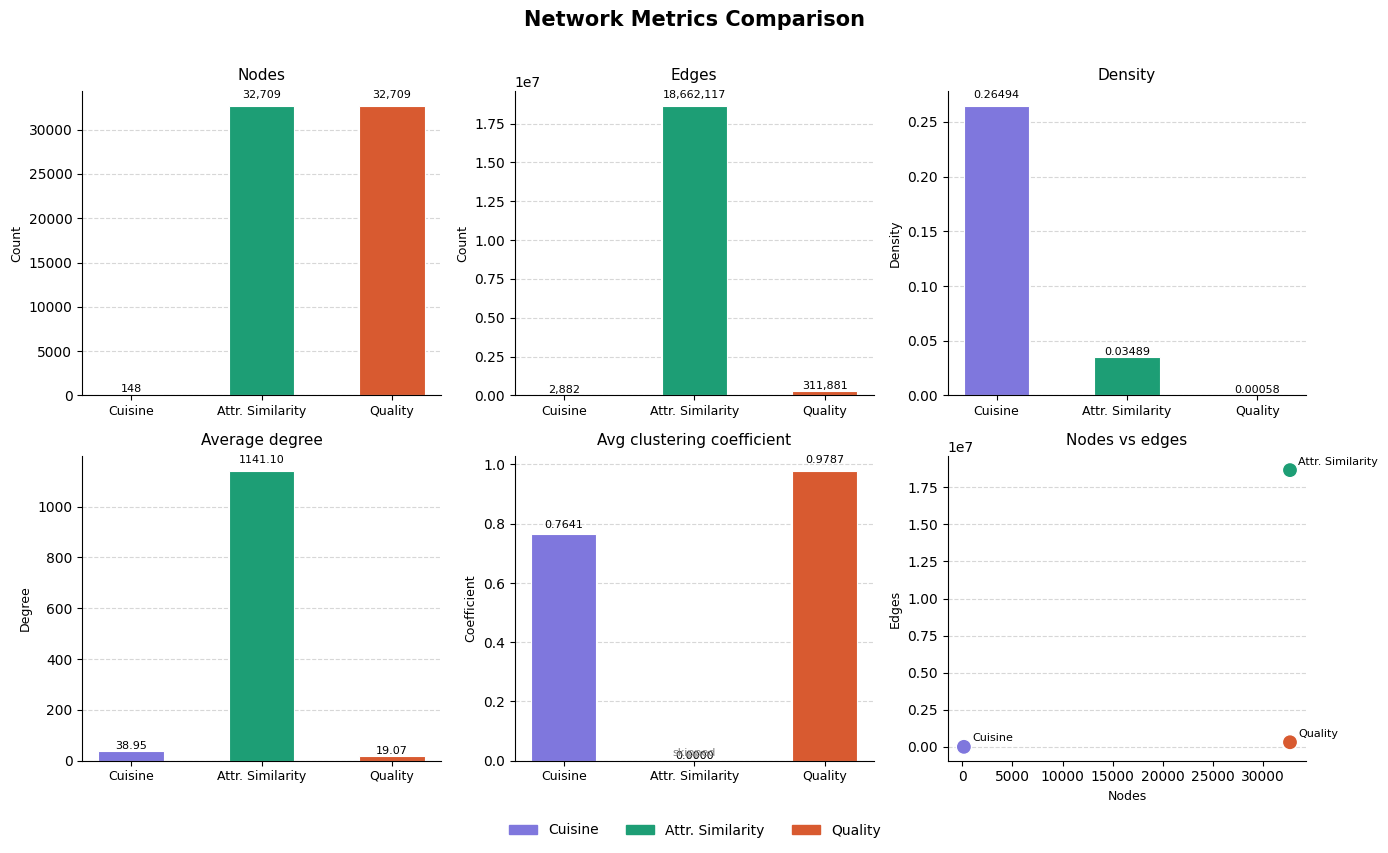

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from networkx.algorithms import approximation

networks = {
    "Cuisine": cuisine_network,
    "Attr. Similarity": G_similarity,
    "Quality": G_quality,
}

# --- Collect metrics ---
labels, nodes, edges, densities, avg_degrees, clusterings = [], [], [], [], [], []

for name, graph in networks.items():
    labels.append(name)
    n = graph.number_of_nodes()
    e = graph.number_of_edges()
    nodes.append(n)
    edges.append(e)
    densities.append(nx.density(graph))
    avg_degrees.append((2 * e) / n if n > 0 else 0)
    if e < 500000:
        clusterings.append(approximation.average_clustering(graph, trials=10000, seed=42))
    else:
        clusterings.append(None)

# --- Plot ---
colors = ['#7F77DD', '#1D9E75', '#D85A30']
x = np.arange(len(labels))
w = 0.5

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("Network Metrics Comparison", fontsize=15, fontweight='bold', y=1.01)

def bar_chart(ax, values, title, ylabel, fmt='{:.4f}', color_list=colors):
    bars = ax.bar(x, values, width=w, color=color_list, edgecolor='white', linewidth=0.8)
    ax.set_title(title, fontsize=11, pad=8)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)
    for bar, val in zip(bars, values):
        if val is not None:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.02,
                    fmt.format(val), ha='center', va='bottom', fontsize=8)

bar_chart(axes[0, 0], nodes,       "Nodes",                   "Count",   '{:,.0f}')
bar_chart(axes[0, 1], edges,       "Edges",                   "Count",   '{:,.0f}')
bar_chart(axes[0, 2], densities,   "Density",                 "Density", '{:.5f}')
bar_chart(axes[1, 0], avg_degrees, "Average degree",          "Degree",  '{:.2f}')

# Clustering — handle skipped networks
clust_vals = [c if c is not None else 0 for c in clusterings]
clust_colors = [colors[i] if clusterings[i] is not None else '#cccccc' for i in range(len(clusterings))]
bar_chart(axes[1, 1], clust_vals, "Avg clustering coefficient", "Coefficient", '{:.4f}', clust_colors)
for i, c in enumerate(clusterings):
    if c is None:
        axes[1, 1].text(x[i], 0.01, "skipped", ha='center', va='bottom', fontsize=8, color='gray')

# Nodes vs Edges scatter
axes[1, 2].scatter(nodes, edges, color=colors, s=120, zorder=3, edgecolors='white', linewidths=1)
for i, name in enumerate(labels):
    axes[1, 2].annotate(name, (nodes[i], edges[i]), textcoords="offset points",
                        xytext=(6, 4), fontsize=8)
axes[1, 2].set_xlabel("Nodes", fontsize=9)
axes[1, 2].set_ylabel("Edges", fontsize=9)
axes[1, 2].set_title("Nodes vs edges", fontsize=11, pad=8)
axes[1, 2].yaxis.grid(True, linestyle='--', alpha=0.5)
axes[1, 2].spines[['top', 'right']].set_visible(False)
axes[1, 2].set_axisbelow(True)

# Legend
patches = [mpatches.Patch(color=colors[i], label=labels[i]) for i in range(len(labels))]
fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, -0.04), frameon=False)

plt.tight_layout()
plt.show()

**7. Centrality Analysis**

- For networks of this size, **Degree Centrality** is the most efficient and conceptually appropriate.
- Degree Centrality simply measures what percentage of the network a node is directly connected to.

In [14]:
# convert id to readable names
id_to_name = dict(zip(balanced["restaurant_link"], balanced["restaurant_name"]))

# Cuisine network: Popular Cuisines
print("--- Top 5 Popular Cuisines ---")

cuisine_centrality = nx.degree_centrality(cuisine_network)

top_cuisines = sorted(cuisine_centrality.items(), key=lambda item: item[1], reverse=True)[:5]

for cuisine, score in top_cuisines:
    print(f"{cuisine.title()}: {score:.4f}")

# Attribute Similarity Network: Representative Restaurants
print("\n--- Top 5 Representative Restaurants (Attribute Similarity) ---")

sim_centrality = nx.degree_centrality(G_similarity)

top_sim_rests = sorted(sim_centrality.items(), key=lambda item: item[1], reverse=True)[:5]

for rest_id, score in top_sim_rests:
    name = id_to_name.get(rest_id, "Unknown Restaurant")
    print(f"{name}: {score:.4f}")

# Quality Correlation Network: Benchmark Restaurants
print("\n--- Top 5 Benchmark Restaurants (Quality Similarity) ---")

qual_centrality = nx.degree_centrality(G_quality)

top_qual_rests = sorted(qual_centrality.items(), key=lambda item: item[1], reverse=True)[:5]

for rest_id, score in top_qual_rests:
    name = id_to_name.get(rest_id, "Unknown Restaurant")
    print(f"{name}: {score:.4f}")

--- Top 5 Popular Cuisines ---
European: 0.8027
Italian: 0.7551
International: 0.7279
Cafe: 0.7279
Fast Food: 0.7211

--- Top 5 Representative Restaurants (Attribute Similarity) ---
Il Mercato Ristorante e Gelateria: 0.4295
Manca Restaurant: 0.4231
Tlusta Kaczka Restaurant: 0.4089
Restauracja Halka Zakopane: 0.3977
La Perle Noire Restaurant and Lounge: 0.3932

--- Top 5 Benchmark Restaurants (Quality Similarity) ---
Oops: 0.5715
Subway: 0.5715
Restaurant Dumbrava: 0.5715
Gostilnitsa  NA DvorT: 0.5715
Bocor Pince & Fogado: 0.5715


C:\Users\Admin\AppData\Local\Temp\ipykernel_32292\2822554581.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cuisine_scores, y=cuisine_names, ax=axes[0], palette='magma')
C:\Users\Admin\AppData\Local\Temp\ipykernel_32292\2822554581.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sim_scores, y=sim_names, ax=axes[1], palette='viridis')
C:\Users\Admin\AppData\Local\Temp\ipykernel_32292\2822554581.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=qual_scores, y=qual_names, ax=axes[2], palette='mako')


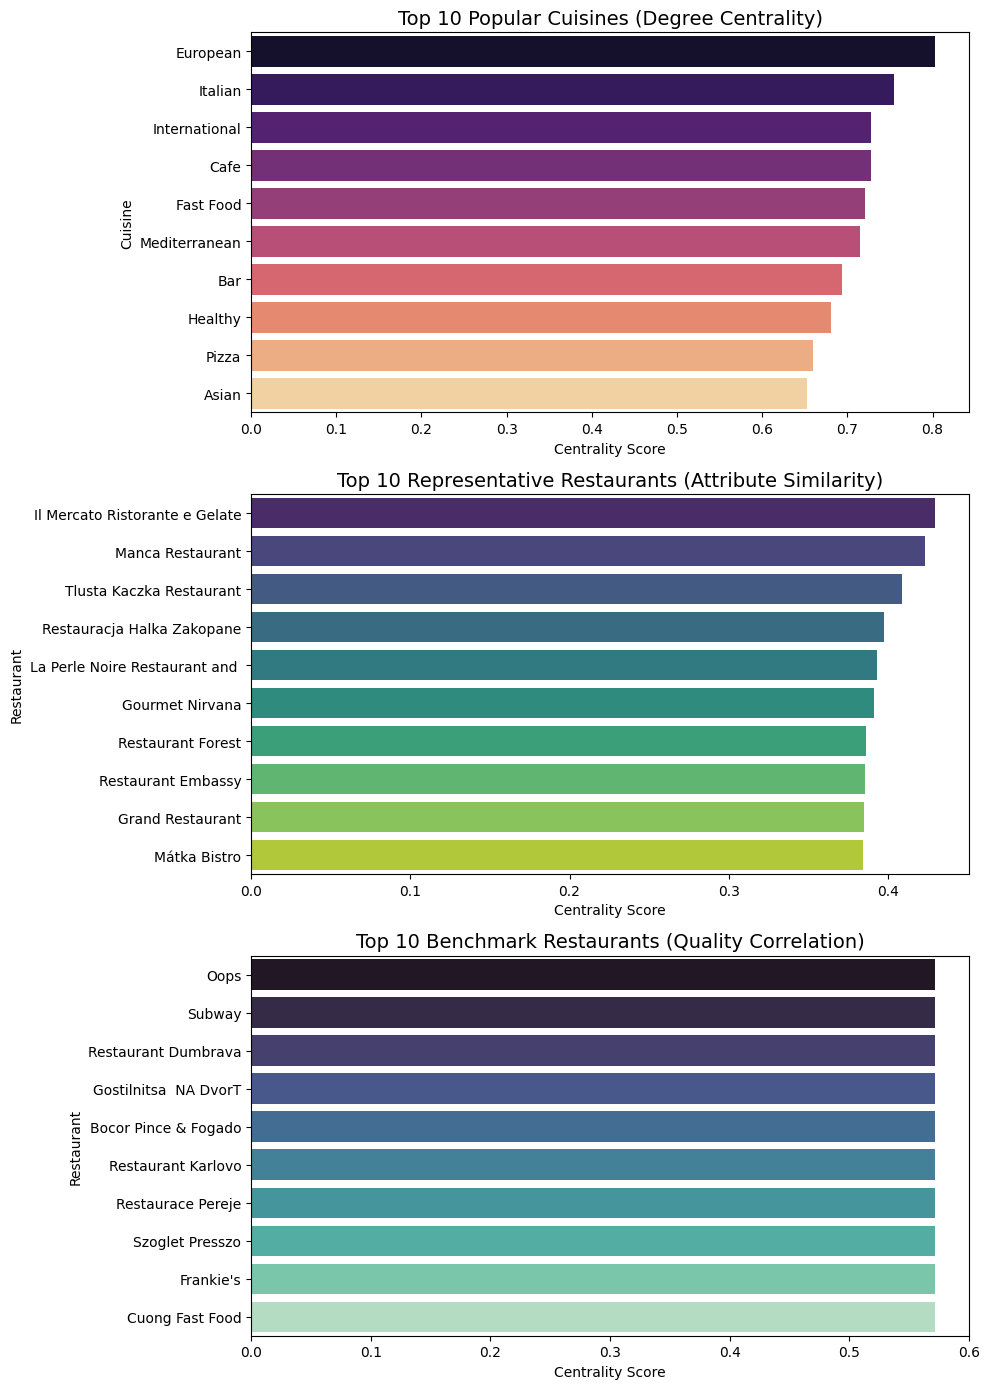

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# Convert id to readable names
id_to_name = dict(zip(balanced["restaurant_link"], balanced["restaurant_name"]))

# --- Calculate Centralities and Get Top 10 ---

# 1. Cuisine network
cuisine_centrality = nx.degree_centrality(cuisine_network)
top_cuisines = sorted(cuisine_centrality.items(), key=lambda item: item[1], reverse=True)[:10]
cuisine_names = [item[0].title() for item in top_cuisines]
cuisine_scores = [item[1] for item in top_cuisines]

# 2. Attribute Similarity Network
sim_centrality = nx.degree_centrality(G_similarity)
top_sim_rests = sorted(sim_centrality.items(), key=lambda item: item[1], reverse=True)[:10]
# The [:30] limits the restaurant name to 30 characters so the chart looks clean
sim_names = [id_to_name.get(item[0], "Unknown Restaurant")[:30] for item in top_sim_rests] 
sim_scores = [item[1] for item in top_sim_rests]

# 3. Quality Correlation Network
qual_centrality = nx.degree_centrality(G_quality)
top_qual_rests = sorted(qual_centrality.items(), key=lambda item: item[1], reverse=True)[:10]
qual_names = [id_to_name.get(item[0], "Unknown Restaurant")[:30] for item in top_qual_rests]
qual_scores = [item[1] for item in top_qual_rests]

# --- Visualize Using Subplots ---

# Create a figure with 3 rows and 1 column
fig, axes = plt.subplots(3, 1, figsize=(10, 14))

# Plot 1: Cuisines
sns.barplot(x=cuisine_scores, y=cuisine_names, ax=axes[0], palette='magma')
axes[0].set_title("Top 10 Popular Cuisines (Degree Centrality)", fontsize=14)
axes[0].set_xlabel("Centrality Score")
axes[0].set_ylabel("Cuisine")

# Plot 2: Similarity
sns.barplot(x=sim_scores, y=sim_names, ax=axes[1], palette='viridis')
axes[1].set_title("Top 10 Representative Restaurants (Attribute Similarity)", fontsize=14)
axes[1].set_xlabel("Centrality Score")
axes[1].set_ylabel("Restaurant")

# Plot 3: Quality
sns.barplot(x=qual_scores, y=qual_names, ax=axes[2], palette='mako')
axes[2].set_title("Top 10 Benchmark Restaurants (Quality Correlation)", fontsize=14)
axes[2].set_xlabel("Centrality Score")
axes[2].set_ylabel("Restaurant")

# Automatically adjust spacing so titles and axes don't overlap
plt.tight_layout()
plt.show()

**8. Community Detection and Interpretation**

- Use the Louvain method to find clusters in two specific networks:
    - Cuisine Network: To find "cuisine clusters" (e.g., do Asian cuisines group together? Do Mediterranean ones form a block?).
    - Similarity Network: To find "restaurant groups" based on shared attributes.
- The Louvain algorithm is a community detection method that groups nodes together if they have a surprisingly high number of edges between them compared to the rest of the network.

In [16]:
import networkx as nx
import pandas as pd

# Cuisine clusters
print("--- Cuisine Network Communities ---")

cuisine_communities = nx.community.louvain_communities(cuisine_network, seed=42)
print(f"Found {len(cuisine_communities)} distinct cuisine clusters.")

# Sort the communities by size (largest first)
sorted_cuisine_comms = sorted(cuisine_communities, key=len, reverse=True)

# Print a sample of the 5 largest cuisine communities
for i, comm in enumerate(sorted_cuisine_comms[:5]):
    sample_cuisines = list(comm)[:5]
    print(f"Cluster {i} ({len(comm)} cuisines): {sample_cuisines}...")

# ------------------------------- Similarity network: restaurant groups --------------------------------
print("\n--- Similarity Network Communities ---")

sim_communities = nx.community.louvain_communities(G_similarity, seed=42)
print(f"Found {len(sim_communities)} distinct restaurant communities.")

# --------- map these communities back to our DataFrame to interpret them --------------
# Create a dictionary where Key = Restaurant_ID, Value = Community_Number
community_map = {}
for i, comm in enumerate(sim_communities):
    for node in comm:
        community_map[node] = i

# Add a new column to our DataFrame with these community labels
balanced['sim_community'] = balanced['restaurant_link'].map(community_map)

# ------- Interprete the communities ---------
# Group by our new community column and calculate the averages for our traits
community_stats = balanced.groupby('sim_community').agg({
    'price_num': 'mean',        # Average Price Level (1 to 3)
    'health_score': 'mean',     # Average Health/Sustainability (0 to 3)
    'quality_score': 'mean',    # Average Review Quality (0.0 to 1.0)
    'restaurant_link': 'count'  # Total size of the community
}).rename(columns={'restaurant_link': 'total_restaurants'})

# Filter out tiny, isolated communities (e.g., clusters with less than 50 restaurants)
significant_comms = community_stats[community_stats['total_restaurants'] > 50]

# Sort by size and display the top 5 largest restaurant communities
print("\n--- Trait Breakdown of Top 5 Largest Restaurant Communities ---")
print(significant_comms.sort_values(by='total_restaurants', ascending=False).head(5))

--- Cuisine Network Communities ---
Found 8 distinct cuisine clusters.
Cluster 0 (34 cuisines): ['israeli', 'fast food', 'azerbaijani', 'sri lankan', 'balti']...
Cluster 1 (32 cuisines): ['brew pub', 'contemporary', 'romanian', 'campania', 'armenian']...
Cluster 2 (26 cuisines): ['welsh', 'southwestern', 'australian', 'spanish', 'bar']...
Cluster 3 (25 cuisines): ['peruvian', 'chinese', 'korean', 'thai', 'japanese fusion']...
Cluster 4 (20 cuisines): ['czech', 'polish', 'puerto rican', 'dining bars', 'belgian']...

--- Similarity Network Communities ---
Found 1351 distinct restaurant communities.

--- Trait Breakdown of Top 5 Largest Restaurant Communities ---
               price_num  health_score  quality_score  total_restaurants
sim_community                                                           
566             2.080485      0.094758       3.005218               8337
488             1.853392      2.372212       3.168274               4304
777             1.796214      0.930401 

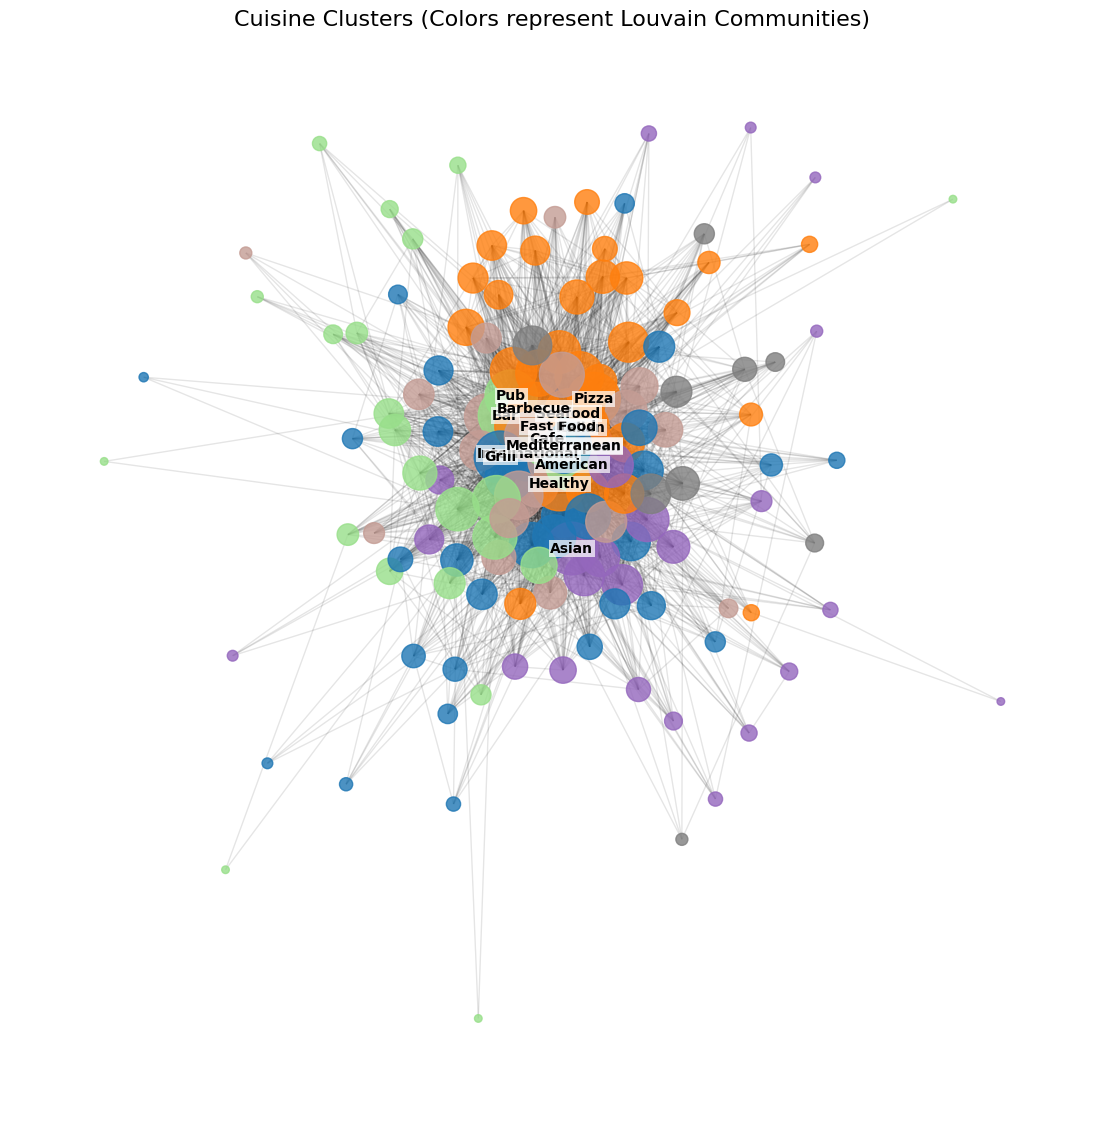

In [17]:
import matplotlib.pyplot as plt
import networkx as nx

# 1. Map each node to its community ID for coloring
node_color_map = {}
for i, comm in enumerate(sorted_cuisine_comms):
    for node in comm:
        node_color_map[node] = i

# Order the colors so they match the exact order of the nodes in the graph
node_colors = [node_color_map[node] for node in cuisine_network.nodes()]

# 2. Draw the Network
plt.figure(figsize=(14, 14))
pos = nx.spring_layout(cuisine_network, k=0.6, seed=42)

# Calculate degrees for node sizes
degrees = dict(cuisine_network.degree())
node_sizes = [v * 15 for v in degrees.values()]

# Draw nodes using a colormap (cmap) to assign different colors to different clusters
nx.draw_networkx_nodes(cuisine_network, pos, node_size=node_sizes, 
                       node_color=node_colors, cmap=plt.cm.tab20, alpha=0.8)
nx.draw_networkx_edges(cuisine_network, pos, alpha=0.1)

# Label only the top 15 to keep it clean (with white background boxes for readability)
top_cuisines = sorted(degrees, key=degrees.get, reverse=True)[:15]
labels = {node: node.title() if node in top_cuisines else '' for node in cuisine_network.nodes()}
nx.draw_networkx_labels(cuisine_network, pos, labels, font_size=10, font_weight="bold",
                        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=1))

plt.title("Cuisine Clusters (Colors represent Louvain Communities)", fontsize=16)
plt.axis('off')
plt.show()

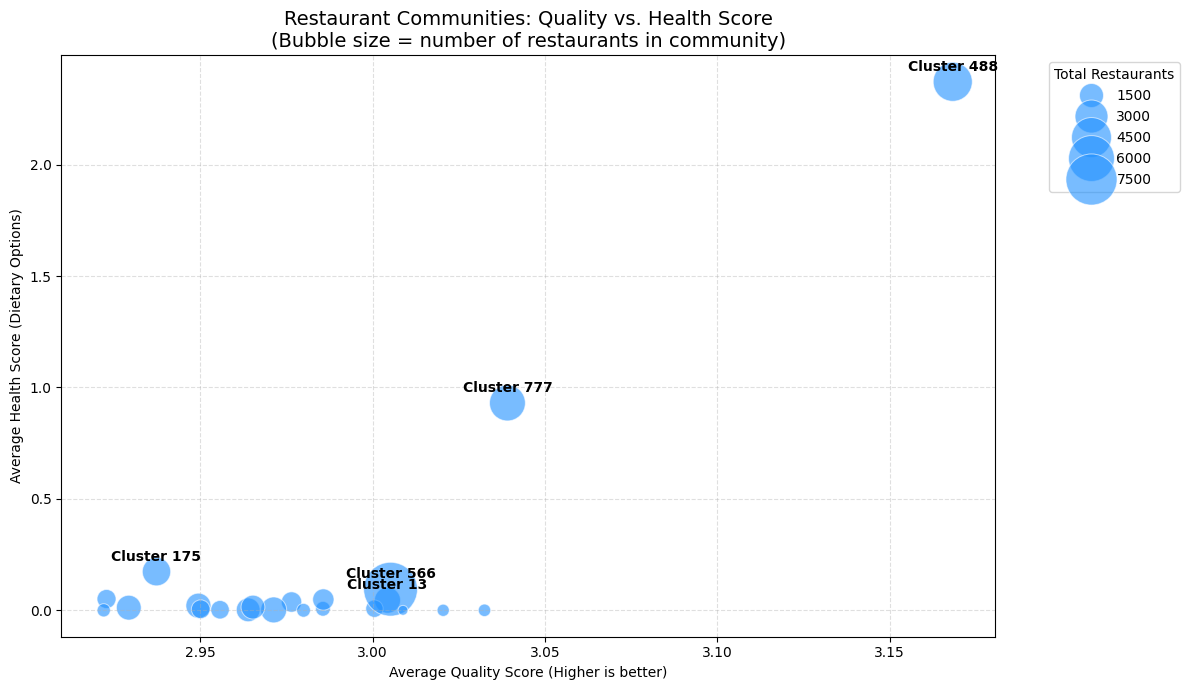

In [18]:
import seaborn as sns

# Reset index so 'sim_community' becomes a normal column we can plot
plot_data = significant_comms.reset_index()

plt.figure(figsize=(12, 7))

# Create a scatter plot where the size of the point ('size' parameter) is based on 'total_restaurants'
sns.scatterplot(
    data=plot_data, 
    x='quality_score', 
    y='health_score', 
    size='total_restaurants', 
    sizes=(50, 1500), # Minimum and maximum bubble sizes
    alpha=0.6, 
    color='dodgerblue'
)

# Add labels to the Top 5 largest communities so we know which bubbles they are
top_5 = plot_data.sort_values(by='total_restaurants', ascending=False).head(5)
for index, row in top_5.iterrows():
    plt.text(row['quality_score'], row['health_score'] + 0.05, 
             f"Cluster {int(row['sim_community'])}", 
             horizontalalignment='center', size='medium', color='black', weight='bold')

plt.title("Restaurant Communities: Quality vs. Health Score\n(Bubble size = number of restaurants in community)", fontsize=14)
plt.xlabel("Average Quality Score (Higher is better)")
plt.ylabel("Average Health Score (Dietary Options)")

# Move the legend outside the plot area so it doesn't cover up data
plt.legend(title="Total Restaurants", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout() # Ensures everything fits in the image
plt.show()

**9. Assortative and Attribute Mixing**

- Goal: analyze whether restaurants connect based on similar price levels, ratings, and dietary features.
- This concept is called **Homophily** (the "birds of a feather flock together" principle), and it is measured mathematically using the **Assortativity Coefficient**.
- How Assortativity Works: The coefficient always outputs a number between -1.0 and 1.0:
    - **Positive (> 0)**: Assortative mixing. Similar restaurants connect to each other (e.g., cheap places link to cheap places).
    - **Zero (~ 0)**: Random mixing. The attribute has absolutely no impact on how the network is structured.
    - **Negative (< 0)**: Disassortative mixing. Opposites attract (e.g., highly rated places link to poorly rated places).
- Steps:
    1. Attaching Attributes to Nodes: `G_similarity` network only contains node IDs (like `g10001637`) and the edges between them. NetworkX does not automatically know their prices or health scores because that data is trapped in Pandas DataFrame. Because of that, before we can calculate assortativity, we have to push those specific columns from Pandas into the NetworkX graph as "node attributes."
    2. Calculate Assortativity using built-in functions

In [19]:
import networkx as nx 

# Create dictionaries where Key = Restaurant_ID and Value = The Attribute
price_dict = dict(zip(balanced["restaurant_link"], balanced["price_num"]))
rating_dict = dict(zip(balanced["restaurant_link"], balanced["quality_score"]))
health_dict = dict(zip(balanced["restaurant_link"], balanced["health_score"]))

# attach attributes to nodes
nx.set_node_attributes(G_similarity, price_dict, "price")
nx.set_node_attributes(G_similarity, rating_dict, "rating")
nx.set_node_attributes(G_similarity, health_dict, "health")

print("Attributes attached successfully")

# calculate assortivity
price_assort = nx.numeric_assortativity_coefficient(G_similarity, "price")
rating_assort = nx.numeric_assortativity_coefficient(G_similarity, "rating")
health_assort = nx.numeric_assortativity_coefficient(G_similarity, "health")

print(f"Price level assortivity: {price_assort:4f}")
print(f"Review rating assortivity: {rating_assort:4f}")
print(f"Health assortivity: {health_assort:4f}")

Attributes attached successfully
Price level assortivity: 0.098868
Review rating assortivity: 0.053768
Health assortivity: 0.643182


Attributes attached successfully. Calculating assortativity...


C:\Users\Admin\AppData\Local\Temp\ipykernel_32292\228591346.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=scores, y=attributes, palette='mako')


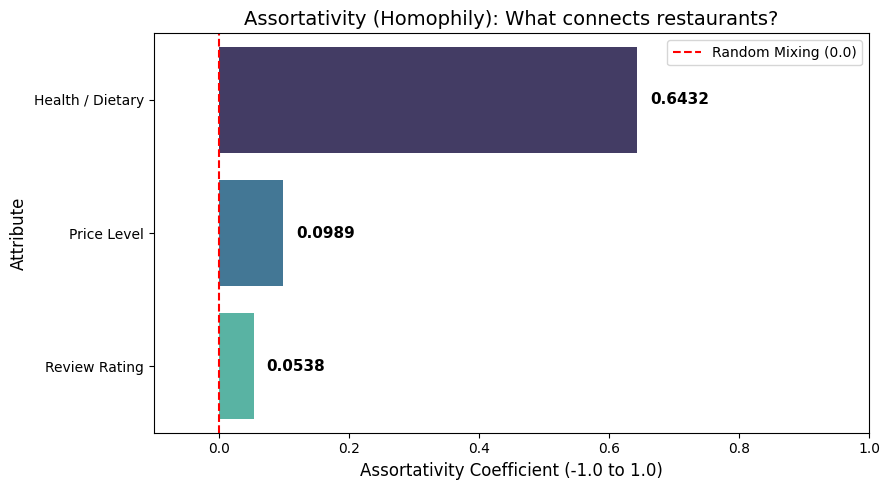

In [20]:
import networkx as nx 
import matplotlib.pyplot as plt
import seaborn as sns

# Create dictionaries where Key = Restaurant_ID and Value = The Attribute
price_dict = dict(zip(balanced["restaurant_link"], balanced["price_num"]))
rating_dict = dict(zip(balanced["restaurant_link"], balanced["quality_score"]))
health_dict = dict(zip(balanced["restaurant_link"], balanced["health_score"]))

# Attach attributes to nodes
nx.set_node_attributes(G_similarity, price_dict, "price")
nx.set_node_attributes(G_similarity, rating_dict, "rating")
nx.set_node_attributes(G_similarity, health_dict, "health")

print("Attributes attached successfully. Calculating assortativity...")

# Calculate assortivity
price_assort = nx.numeric_assortativity_coefficient(G_similarity, "price")
rating_assort = nx.numeric_assortativity_coefficient(G_similarity, "rating")
health_assort = nx.numeric_assortativity_coefficient(G_similarity, "health")

# ----------------- Visualization -----------------
attributes = ['Health / Dietary', 'Price Level', 'Review Rating']
scores = [health_assort, price_assort, rating_assort]

plt.figure(figsize=(9, 5))

# Create horizontal bar chart
sns.barplot(x=scores, y=attributes, palette='mako')

# Add a vertical line at 0 to represent "Random Mixing"
plt.axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Random Mixing (0.0)')

# Since assortativity maxes out at 1.0, setting the x-limit gives a true sense of scale
# We extend slightly below 0 in case there's slight disassortativity
plt.xlim(-0.1, 1.0) 

plt.title("Assortativity (Homophily): What connects restaurants?", fontsize=14)
plt.xlabel("Assortativity Coefficient (-1.0 to 1.0)", fontsize=12)
plt.ylabel("Attribute", fontsize=12)

# Add exact score labels to the end of each bar
for index, value in enumerate(scores):
    plt.text(value + 0.02, index, f'{value:.4f}', va='center', fontsize=11, fontweight='bold')

plt.legend()
plt.tight_layout()
plt.show()

**10. K-core and Backbone Analysis**

- Goal: remove the noise to find the structural center of the network
    - K-Core Decomposition: remove the outer layers of the network until it only remains the core part.
    - Backbone Filtering: remove the weakest edges so only the most important one remains
- For this task, use **Attribute Similarity Network**
    - K-Core: NetworkX has a built-in function `nx.k_core()`. By default, it will fin the main core and we will extract those main core nodes, labelling them as "Core" and anything else as "Peripheral"
    - Comparing: use Pandas `.groupby()` to compare their average quality, health score, and degree/connections.
    - Backbone filtering: do a simple Degree-based backbone filter to remove restaurants that have only 1-2 connections and keep only nodes having >= 3 connections.

In [21]:
import networkx as nx
import pandas as pd

# ---------------------- K-core decomposition (identify core and peripheral) ------------------------
print("--- K-core Analysis ---") 

G_similarity.remove_edges_from(nx.selfloop_edges(G_similarity)) 

core_graph = nx.k_core(G_similarity)
core_nodes = set(core_graph.nodes())

print(f"Total restaurants: {G_similarity.number_of_nodes()}")
print(f"Restaurants in the main core: {len(core_nodes)}")
print(f"Restaurants in the periphery: {G_similarity.number_of_nodes() - len(core_nodes)}")

# label if a restaurant is Core or Peripheral 
balanced["network_position"] = balanced["restaurant_link"].apply(lambda x: 'Core' if x in core_nodes else 'Peripheral')

# calculate also Popularity
degree_dict = dict(G_similarity.degree())
balanced["popularity_degree"] = balanced["restaurant_link"].map(degree_dict).fillna(0)

# ----------------------------- Compare core vs. peripheral ------------------------------
print("\n--- Comparing Core vs. Peripheral Restaurants ---")
core_comparison = balanced.groupby('network_position').agg({
    'quality_score': 'mean',        # Quality
    'health_score': 'mean',         # Sustainability
    'popularity_degree': 'mean',    # Popularity
}).round(3)
print(core_comparison)

#  ---------------------------------- Backbone filtering -----------------------------------
print("\n--- Simple Backbone Filtering ---")
strong_nodes = [node for node, deg in G_similarity.degree() if deg >= 3]
backbone = G_similarity.subgraph(strong_nodes).copy()

print(f"Original Edges: {G_similarity.number_of_edges()}")
print(f"Backbone Edges: {backbone.number_of_edges()}")
print("Weak edges successfully removed!")

--- K-core Analysis ---
Total restaurants: 32709
Restaurants in the main core: 3251
Restaurants in the periphery: 29458

--- Comparing Core vs. Peripheral Restaurants ---
                  quality_score  health_score  popularity_degree
network_position                                                
Core                      3.190         2.559           4723.147
Peripheral                2.987         0.177            743.036

--- Simple Backbone Filtering ---
Original Edges: 18659546
Backbone Edges: 18659080
Weak edges successfully removed!


**11. Health and Sustainability Network Position**

- Goal: Analyze 2 things
    1. Where do vegetarian/vegan/gluten-free restaurants appear? Are they central (Core) or peripheral?
    2. Do healthy restaurants form clusters?
- Because we already calculated `network_position` (Core vs. Peripheral) in Task 10 and `sim_community` (clusters) in Task 8, we don't need to run any heavy NetworkX math. We can answer this entirely using fast Pandas `.groupby()` functions.
- For part 1: Since `vegetarian_friendly`, `vegan_options`, and `gluten_free` columns are **binary** (0 or 1), calculating the `mean()` of those columns actually gives you the exact percentage of restaurants that have those traits. We will group by `network_position` to see if the **Core** has a higher or lower percentage of vegan places than the **Periphery**.
- For part 2: look at **Louvain communities** and sort them by their **average `health_score`**. If we find a few specific clusters where the health score is nearly a perfect `3.0`, it proves that healthy restaurants **tightly cluster** together.

In [22]:
import pandas as pd

# -------------------- 1. Determine if health restaurants are core or peripheral --------------------------
print("--- Distribution of Healthy Restaurants: Core vs Periphery ---")

# Calculate the mean of  binary dietary columns and overall health score
health_position_stats = balanced.groupby('network_position').agg({
    'vegetarian_friendly': 'mean',
    'vegan_options': 'mean',
    'gluten_free': 'mean',
    'health_score': 'mean'
}).round(3)

# Multiply the binary columns by 100 to make them readable as percentages
health_position_stats[['vegetarian_friendly', 'vegan_options', 'gluten_free']] *= 100

print("Percentage (%) of restaurants offering dietary options:")
print(health_position_stats)

# --------------------------- 2. Determine if restaurans form clusters -------------------------
# Group by the communities we found in Task 8
community_health = balanced.groupby('sim_community').agg({
    'health_score': 'mean',
    'vegan_options': 'mean',         
    'restaurant_link': 'count' # Total size of the community
}).rename(columns={'restaurant_link': 'total_restaurants'})

valid_communities = community_health[community_health["total_restaurants"] > 20]
top_healthy_clusters = valid_communities.sort_values(by='health_score', ascending=False).head(5)
top_healthy_clusters['vegan_options'] = (top_healthy_clusters['vegan_options'] * 100).round(1)

print("Top 5 Healthiest Restaurant Communities:")
print(top_healthy_clusters.round(3))

--- Distribution of Healthy Restaurants: Core vs Periphery ---
Percentage (%) of restaurants offering dietary options:
                  vegetarian_friendly  vegan_options  gluten_free  \
network_position                                                    
Core                            100.0          100.0         55.9   
Peripheral                       14.2            0.3          3.1   

                  health_score  
network_position                
Core                     2.559  
Peripheral               0.177  
Top 5 Healthiest Restaurant Communities:
               health_score  vegan_options  total_restaurants
sim_community                                                
488                   2.372           81.2               4304
777                   0.930            0.5               3592
175                   0.173            0.1               2174
566                   0.095            1.8               8337
929                   0.051            0.2                8

C:\Users\Admin\AppData\Local\Temp\ipykernel_32292\2823772444.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=health_position_stats.reset_index(),


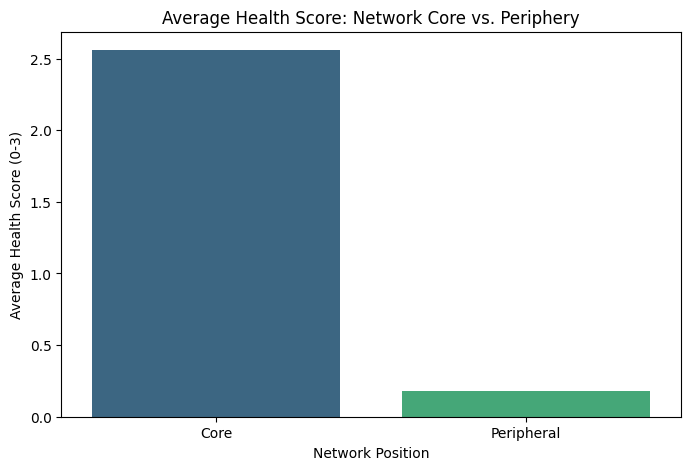

In [23]:
plt.figure(figsize=(8, 5))
sns.barplot(data=health_position_stats.reset_index(), 
            x='network_position', y='health_score', palette='viridis')

plt.title("Average Health Score: Network Core vs. Periphery")
plt.xlabel("Network Position")
plt.ylabel("Average Health Score (0-3)")
plt.show()

**12. Popularity vs Quality vs Structure**

- Goal: compare three things and identify specific mismatches
    1. Popularity: High number of reviews
    2. Quality: High review scores (`quality_score` from Task 1).
    3. Structure: Centrality (`popularity_degree` or `network_position` from Task 10).
- Use **Quantiles** to avoid hardcoding numbers: find the top **10% most-reviewed restaurants**, the **bottom 25% lowest-rated restaurant**s, and the **top 10% highest-rated restaurants**.
- Then, filter mismatches:
    - Mismatch 1 (**The Tourist Trap**): Popular (Top 10% reviews) but Low Quality (Bottom 25% score).
    - Mismatch 2 (**The Hidden Gem**): High Quality (Top 10% score) but Peripheral (Isolated from the core network).

In [24]:
import pandas as pd

balanced["total_reviews_count"] = pd.to_numeric(balanced["total_reviews_count"], errors="coerce").fillna(0)

# Calculate Quantiles
# Top 10% most reviewed restaurants
high_popularity_threshold = balanced["total_reviews_count"].quantile(0.90)

# Bottom 25% of quality scores
low_quality_threshold = balanced['quality_score'].quantile(0.25)

# Top 10% of quality scores
high_quality_threshold = balanced['quality_score'].quantile(0.90)

print("--- Calculated Thresholds ---")
print(f"High Popularity (>90th percentile): {high_popularity_threshold} reviews")
print(f"Low Quality (<25th percentile): {low_quality_threshold:.3f} score")
print(f"High Quality (>90th percentile): {high_quality_threshold:.3f} score\n")

# Identify mismatches

# Mismatch 1
tourist_traps = balanced[
    (balanced["total_reviews_count"] >= high_popularity_threshold) & 
    (balanced['quality_score'] <= low_quality_threshold)
]

print("--- Mismatch 1: Popular but Low Quality ('Tourist Traps') ---")
print(f"Found {len(tourist_traps)} restaurants fitting this description.")
# Display the top 5 worst offenders (sorted by most reviews)
print(tourist_traps[['restaurant_name', 'country', "total_reviews_count", 'quality_score']].sort_values(by="total_reviews_count", ascending=False).head(5))

# Mismatch 2
hidden_gems = balanced[
    (balanced['quality_score'] >= high_quality_threshold) & 
    (balanced['network_position'] == 'Peripheral')
]

print("\n--- Mismatch 2: High Quality but Peripheral ('Hidden Gems') ---")
print(f"Found {len(hidden_gems)} restaurants fitting this description.")
# Display the top 5 hidden gems (sorted by highest quality)
print(hidden_gems[['restaurant_name', 'country', 'cuisines', 'quality_score', 'popularity_degree']].sort_values(by='quality_score', ascending=False).head(5))

--- Calculated Thresholds ---
High Popularity (>90th percentile): 164.0 reviews
Low Quality (<25th percentile): 3.000 score
High Quality (>90th percentile): 3.375 score

--- Mismatch 1: Popular but Low Quality ('Tourist Traps') ---
Found 1659 restaurants fitting this description.
             restaurant_name         country  total_reviews_count  \
39767          Le Train Bleu          France               6030.0   
730972               DaMimmo           Italy               3693.0   
94035            Diego Plage          France               3575.0   
1036248  Kolkovna V Kolkovně  Czech Republic               3458.0   
503440             Donatello         England               3163.0   

         quality_score  
39767            3.000  
730972           2.875  
94035            2.750  
1036248          2.875  
503440           3.000  

--- Mismatch 2: High Quality but Peripheral ('Hidden Gems') ---
Found 3257 restaurants fitting this description.
                      restaurant_name  c

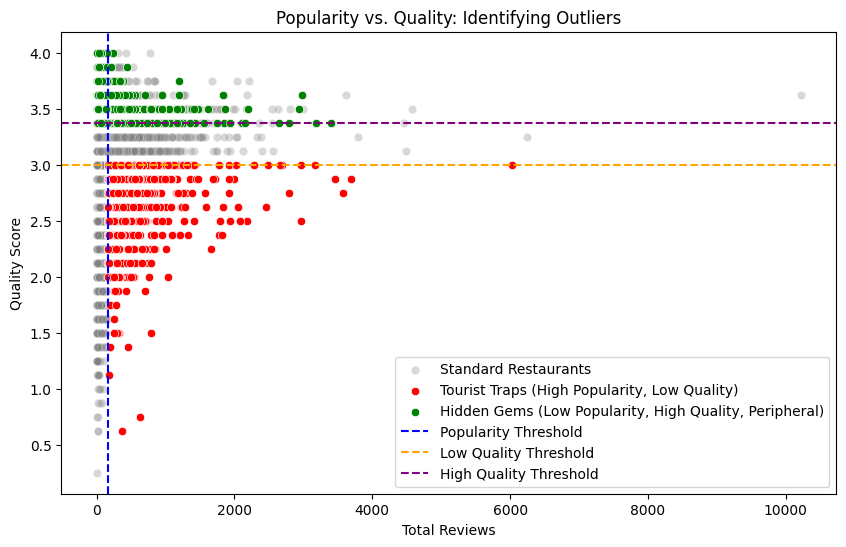

In [25]:
import seaborn as sns

plt.figure(figsize=(10, 6))

# Create scatter plot
sns.scatterplot(data=balanced, x='total_reviews_count', y='quality_score', 
                alpha=0.3, color='grey', label='Standard Restaurants')

# Highlight Tourist Traps
sns.scatterplot(data=tourist_traps, x='total_reviews_count', y='quality_score', 
                color='red', label='Tourist Traps (High Popularity, Low Quality)')

# Highlight Hidden Gems
sns.scatterplot(data=hidden_gems, x='total_reviews_count', y='quality_score', 
                color='green', label='Hidden Gems (Low Popularity, High Quality, Peripheral)')

# Draw threshold lines
plt.axvline(x=high_popularity_threshold, color='blue', linestyle='--', label='Popularity Threshold')
plt.axhline(y=low_quality_threshold, color='orange', linestyle='--', label='Low Quality Threshold')
plt.axhline(y=high_quality_threshold, color='purple', linestyle='--', label='High Quality Threshold')

plt.title("Popularity vs. Quality: Identifying Outliers")
plt.xlabel("Total Reviews")
plt.ylabel("Quality Score")
plt.legend()
plt.show()

**13. Finland vs Other Regions (Comparative Analysis)**

- Goal: to compare Finland against the other regions specifically regarding: network density, clustering, centrality distribution, community structure, and the position of healthy/sustainable restaurants. Then, interprete what it means for their food behavior and culture.
- Steps:
    1. **Slice the Network**: extract "Subgraphs" from the main `G_similarity` network—one exclusively for Finland, and others for the remaining regions. This lets us measure their specific densities and average degrees.
    2. **Slice the Data**: group restaurants by region to compare their sustainability percentages (vegan/vegetarian) and average quality.

In [26]:
# Slice the data by grouping
print("--- Cultural Food Behavior & Sustainability ---")

behavior_stats = balanced.groupby('region_group').agg({
    'vegetarian_friendly': 'mean',
    'vegan_options': 'mean',
    'gluten_free': 'mean',
    'quality_score': 'mean',
    'price_num': 'mean'
}).round(3)

# Convert dietary columns to percentages for easier reading
behavior_stats[['vegetarian_friendly', 'vegan_options', 'gluten_free']] *= 100

print("Percentage of restaurants with dietary options & overall traits:")
print(behavior_stats)

# Slice the network using subgraphs
print("\n--- Network Structure Comparison (Similarity Network) ---")

# get a list of all regions in the dataset
regions = balanced["region_group"].unique()

for region in regions: 
    #Get the IDs of all restaurants in this specific region
    region_nodes = balanced[balanced["region_group"] == region]['restaurant_link'].tolist()

    region_subgraph = G_similarity.subgraph(region_nodes).copy() # use .copy() to not accidentally modify the original graph

    # calculate metrics
    nodes_num = region_subgraph.number_of_nodes()
    edges_num = region_subgraph.number_of_edges()
    density = nx.density(region_subgraph)

    if nodes_num > 0:
        ave_deg = (2 * edges_num) / nodes_num
    else:
        ave_deg = 0
    
    print(f"[{region}]")
    print(f"  Nodes: {nodes_num} | Edges: {edges_num}")
    print(f"  Density: {density:.6f} | Avg Degree: {avg_degree:.2f}")


--- Cultural Food Behavior & Sustainability ---
Percentage of restaurants with dietary options & overall traits:
                 vegetarian_friendly  vegan_options  gluten_free  \
region_group                                                       
Eastern Europe                  15.7            6.8          4.0   
Finland                         17.2            8.6          6.7   
Northern Europe                 16.9            7.3          5.8   
Southern Europe                 29.5           13.8         13.6   
Western Europe                  33.4           13.5         11.0   

                 quality_score  price_num  
region_group                               
Eastern Europe           3.034      1.795  
Finland                  2.983      1.892  
Northern Europe          2.977      1.921  
Southern Europe          3.017      1.775  
Western Europe           3.025      1.827  

--- Network Structure Comparison (Similarity Network) ---
[Eastern Europe]
  Nodes: 6945 | Edges: 803

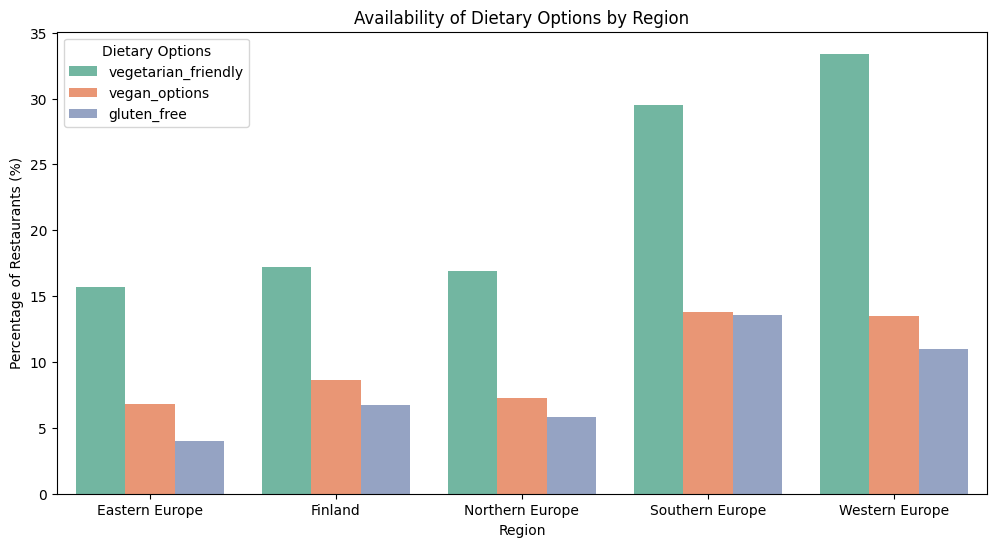

In [27]:
# Melt the DataFrame so Seaborn can easily plot it as grouped bars
behavior_melted = behavior_stats[['vegetarian_friendly', 'vegan_options', 'gluten_free']].reset_index().melt(
    id_vars='region_group', 
    var_name='Dietary Type', 
    value_name='Percentage'
)

plt.figure(figsize=(12, 6))
sns.barplot(data=behavior_melted, x='region_group', y='Percentage', hue='Dietary Type', palette='Set2')

plt.title("Availability of Dietary Options by Region")
plt.xlabel("Region")
plt.ylabel("Percentage of Restaurants (%)")
plt.legend(title="Dietary Options")
plt.show()

**14. Geographic Influence Analysis**

- Goal: to answer the question "Does physical location dictate a restaurant's identity, or do similarities transcend borders?"
- We are looking for Geographic Homophily: determine if restaurants only connect to other restaurants in their own country, or if a high-end vegan cafe in Helsinki is strongly connected to a high-end vegan cafe in Rome.
- Steps: 
    1. **Geographic Assortativity**: Just like in Task 9, we will measure how strongly "Country" drives the connections in the `G_similarity` network. (the only difference is that "Country" now is a text not a numerical value)
    2. **Community Mapping**: We will look at the restaurant clusters in Task 8 and see if they are localized (e.g., Cluster 0 is 100% Italian) or international (e.g., Cluster 1 contains 10 different countries).

In [28]:
import pandas as pd
import networkx as nx

# Geographic Assortivity
print("--- Geographic Assortativity ---")

# attach "Country" attribute to our network nodes
country_dict = dict(zip(balanced["restaurant_link"], balanced["country"]))
nx.set_node_attributes(G_similarity, country_dict, "country")
country_assort = nx.attribute_assortativity_coefficient(G_similarity, "country")

print(f"Country Assortativity Coefficient: {country_assort:.4f}")

if country_assort > 0.5: 
    print("Interpretation: HIGH geographic isolation. Restaurants mostly connect within their own borders.")
if country_assort > 0.1:
    print("Interpretation: MODERATE geographic influence. Borders matter, but international connections exist.")
else: 
    print("Interpretation: LOW geographic influence. The network transcends borders based on shared traits.")


# 
# Group by our existing communities (.groupby()), and count how many restaurants belong to each country (.size())
# unstack() turn the vertical list a wide, 2D table. The Communities become the rows, and the Countries become the columns.
# fill_value = 0: turn NaN to 0
community_geography = balanced.groupby(['sim_community', 'country']).size().unstack(fill_value=0)

# Add a 'Total' column so we can easily find the biggest communities
# axis=1 means sum horizontally
community_geography['Total_Size'] = community_geography.sum(axis=1)

# Get the biggest clusters 
top_geo_communities = community_geography.sort_values(by='Total_Size', ascending=False).head(5)

for index, row in top_geo_communities.iterrows():
    total = row['Total_Size']

    # Drop the total column, sort the countries by count, and grab the top 3
    top_countries = row.drop('Total_Size').sort_values(ascending=False).head(3)

    print(f"Cluster {index} ({total} restaurants):")
    for country, count in top_countries.items():
        if count > 0:
            percentage = (count / total) * 100
            print(f"   - {country}: {count} ({percentage:.1f}%)")

--- Geographic Assortativity ---
Country Assortativity Coefficient: 0.0997
Interpretation: LOW geographic influence. The network transcends borders based on shared traits.
Cluster 566 (8337 restaurants):
   - Finland: 1695 (20.3%)
   - Sweden: 1456 (17.5%)
   - Denmark: 720 (8.6%)
Cluster 488 (4304 restaurants):
   - Italy: 706 (16.4%)
   - Finland: 685 (15.9%)
   - England: 633 (14.7%)
Cluster 777 (3592 restaurants):
   - Italy: 664 (18.5%)
   - Finland: 446 (12.4%)
   - Germany: 339 (9.4%)
Cluster 175 (2174 restaurants):
   - Finland: 625 (28.7%)
   - Sweden: 463 (21.3%)
   - Denmark: 224 (10.3%)
Cluster 13 (1789 restaurants):
   - Finland: 585 (32.7%)
   - Sweden: 279 (15.6%)
   - Czech Republic: 138 (7.7%)


--- Geographic Assortativity ---
Country Assortativity Coefficient: 0.0997
Interpretation: LOW geographic influence. The network transcends borders based on shared traits.



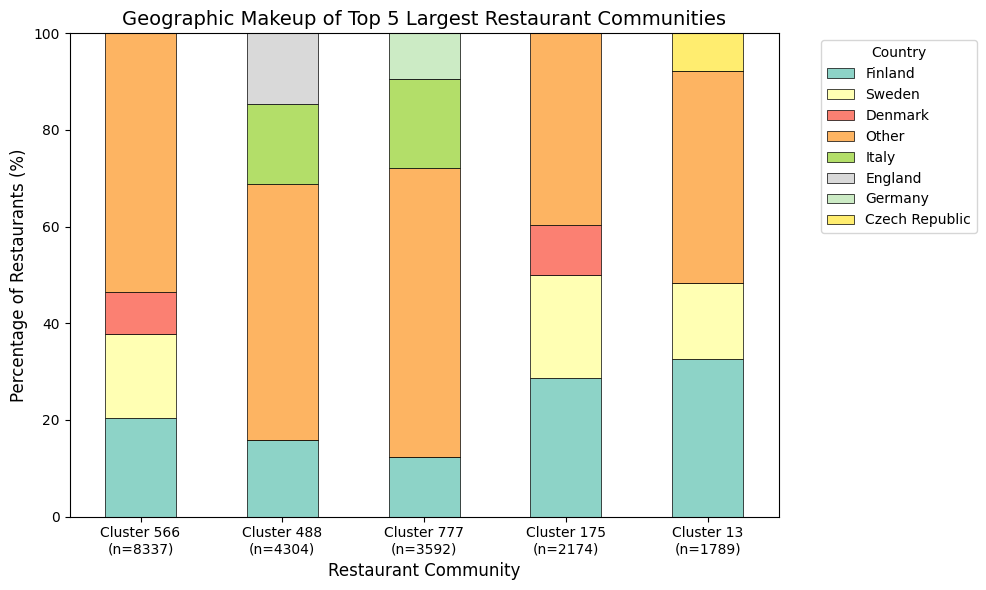

In [29]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# ----------------- 1. Geographic Assortativity -----------------
print("--- Geographic Assortativity ---")

# attach "Country" attribute to our network nodes
country_dict = dict(zip(balanced["restaurant_link"], balanced["country"]))
nx.set_node_attributes(G_similarity, country_dict, "country")
country_assort = nx.attribute_assortativity_coefficient(G_similarity, "country")

print(f"Country Assortativity Coefficient: {country_assort:.4f}")

if country_assort > 0.5: 
    print("Interpretation: HIGH geographic isolation. Restaurants mostly connect within their own borders.")
elif country_assort > 0.1:
    print("Interpretation: MODERATE geographic influence. Borders matter, but international connections exist.")
else: 
    print("Interpretation: LOW geographic influence. The network transcends borders based on shared traits.\n")


# ----------------- 2. Community Geography Visualization -----------------
# Group by communities and count how many restaurants belong to each country
community_geography = balanced.groupby(['sim_community', 'country']).size().unstack(fill_value=0)
community_geography['Total_Size'] = community_geography.sum(axis=1)

# Get the top 5 biggest clusters 
top_geo_communities = community_geography.sort_values(by='Total_Size', ascending=False).head(5)

# Prepare data for plotting
plot_data = []

for index, row in top_geo_communities.iterrows():
    total = row['Total_Size']
    
    # Sort countries by count
    sorted_countries = row.drop('Total_Size').sort_values(ascending=False)
    
    # Grab the top 3 explicitly, bundle the rest into "Other"
    top_3 = sorted_countries.head(3)
    other_count = sorted_countries.iloc[3:].sum()
    
    # Calculate percentages
    cluster_data = {'Cluster': f"Cluster {index}\n(n={int(total)})"}
    for country, count in top_3.items():
        if count > 0:
            cluster_data[country] = (count / total) * 100
            
    if other_count > 0:
        cluster_data['Other'] = (other_count / total) * 100
        
    plot_data.append(cluster_data)

# Convert to DataFrame and fill missing columns with 0
plot_df = pd.DataFrame(plot_data).set_index('Cluster').fillna(0)

# Plotting the 100% Stacked Bar Chart
# Using a colormap that provides distinct colors for different countries
ax = plot_df.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set3', edgecolor='black', linewidth=0.5)

plt.title("Geographic Makeup of Top 5 Largest Restaurant Communities", fontsize=14)
plt.xlabel("Restaurant Community", fontsize=12)
plt.ylabel("Percentage of Restaurants (%)", fontsize=12)

# Keep the labels horizontal so they are easy to read
plt.xticks(rotation=0)

# Move the legend outside the chart to avoid covering the bars
plt.legend(title="Country", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()